# Data-saving evaluation — per-SNR visualizations + tables
Reduction (x vs naive save-all) + signal retention per detector, on a physical **SNR axis** mapped
from attenuation via the baseline SNR calibration (`snr_measurement`, which `build_snr_results` wraps):
`snr_db = snr0_ref - attenuation_db`, with `snr0_ref` = median calibrated 0 dB SNR of the signals.
Numbers come from `plot_data_saving.py` (snipper frequency-mode byte accounting + thresholded time-slice).

In [1]:
import json, os, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

BATCH = Path(os.environ.get("DS_BATCH_ROOT", "/tmp/ds_batch"))
OUT = BATCH / "data_saving_figs"
TABLE = OUT / "data_saving_table.csv"
CALIB = BATCH / "snr_calibration.json"
CAP0 = Path("/home/bqn82/captures/attenuation_dB_0.sigmf-data")
_BC = Path.home()/"Holohub-Signal-Detection/applications/usrp_wideband_signal_detection/infocom_evals/baseline_comparisons"

## SNR mapping (baseline calibration -> snr0_ref)

In [2]:
if CALIB.exists():
    snr0_ref = float(json.load(open(CALIB))["snr0_ref_db"])
    print(f"loaded snr0_ref = {snr0_ref:.2f} dB  (from {CALIB.name})")
else:
    sys.path.insert(0, str(_BC)); import snr_measurement as sm
    calib = sm.calibrate_from_capture(CAP0, CAP0.with_suffix(".sigmf-meta"), sm.SnrConfig())
    snr0_ref = float(np.median([r["snr0_db"] for r in calib["calibration"]]))
    print(f"calibrated snr0_ref = {snr0_ref:.2f} dB")
print(f"SNR(dB) = {snr0_ref:.1f} - attenuation   (att 0 -> {snr0_ref:.0f}, 30 -> {snr0_ref-30:.0f}, 60 -> {snr0_ref-60:.0f})")

loaded snr0_ref = 54.02 dB  (from snr_calibration.json)
SNR(dB) = 54.0 - attenuation   (att 0 -> 54, 30 -> 24, 60 -> -6)


## Data-saving table (SNR-mapped)

In [3]:
df = pd.read_csv(TABLE)
df["snr_db"] = (snr0_ref - df["attenuation_db"]).round(1)
df = df.sort_values(["detector", "snr_db"]).reset_index(drop=True)
has_ts = "timeslice_reduction_x" in df.columns
cols = ["detector", "attenuation_db", "snr_db", "reduction_x"] + (["timeslice_reduction_x"] if has_ts else []) + ["retention"]
print(f"detectors: {sorted(df.detector.unique())}  | time-slice column: {has_ts}")
display(df[cols].round(3))
display(df.pivot_table(index="detector", columns="snr_db", values="reduction_x").round(2))

detectors: ['3dB_power', 'blob_detection', 'coherent_power', 'cuda_dino', 'finetuned_dino', 'finetuned_dino_m2', 'yolo26m', 'yolo26s']  | time-slice column: True


,detector,attenuation_db,snr_db,reduction_x,timeslice_reduction_x,retention
0,3dB_power,60,-6.0,1.000,1.000,1.000
1,3dB_power,55,-1.0,1.000,1.000,1.000
2,3dB_power,50,4.0,1.000,1.000,1.000
3,3dB_power,45,9.0,1.000,1.000,1.000
4,3dB_power,40,14.0,1.000,1.000,1.000
...,...,...,...,...,...,...
99,yolo26s,20,34.0,3.242,1.857,0.907
100,yolo26s,15,39.0,3.057,1.819,0.919
101,yolo26s,10,44.0,3.217,1.834,0.904
102,yolo26s,5,49.0,3.109,1.840,0.897


snr_db,-6.0,-1.0,4.0,9.0,14.0,19.0,24.0,29.0,34.0,39.0,44.0,49.0,54.0
detector,,,,,,,,,,,,,
3dB_power,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
blob_detection,1.00,1.00,1.00,1.00,1.00,1.22,1.54,1.71,1.56,1.62,1.49,1.54,1.48
coherent_power,6.37,5.59,5.33,4.75,3.00,2.11,1.91,2.21,2.27,2.22,1.82,1.47,1.10
cuda_dino,1.01,1.02,1.05,1.14,1.45,1.40,1.41,1.48,1.55,1.32,1.32,1.27,1.13
finetuned_dino,83.12,80.27,26.46,13.44,2.88,2.89,3.10,3.01,3.29,3.06,3.26,3.13,2.89
finetuned_dino_m2,4.32,2.65,2.63,3.05,2.91,2.88,3.09,2.99,3.26,3.07,3.24,3.10,2.87
yolo26m,2.71,2.65,2.73,3.05,2.86,2.78,3.04,2.98,3.17,2.99,3.09,3.01,2.88
yolo26s,3.59,2.74,2.74,3.11,2.90,2.86,3.08,2.96,3.24,3.06,3.22,3.11,2.89


## Figures (SNR axis)

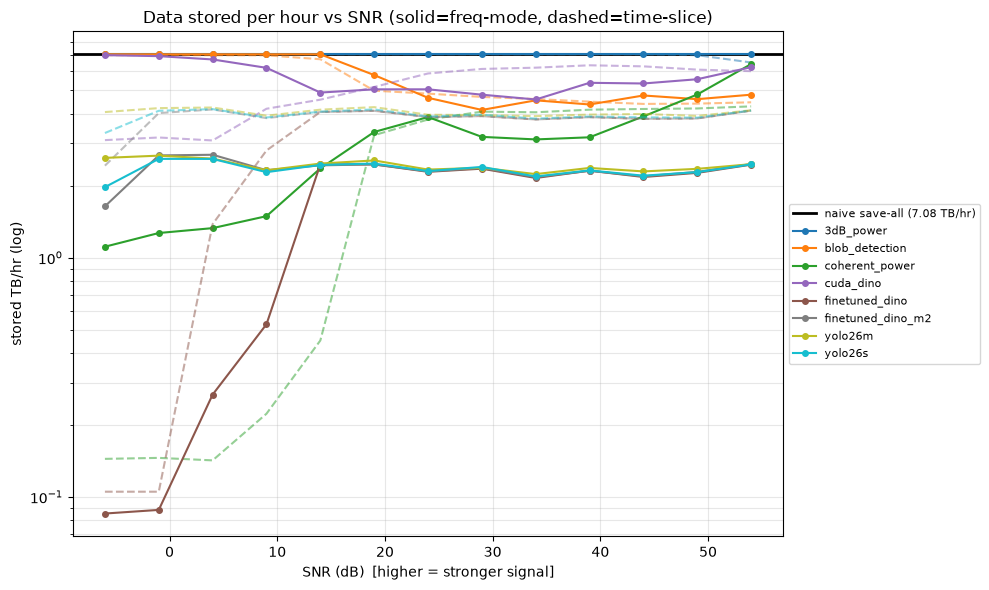

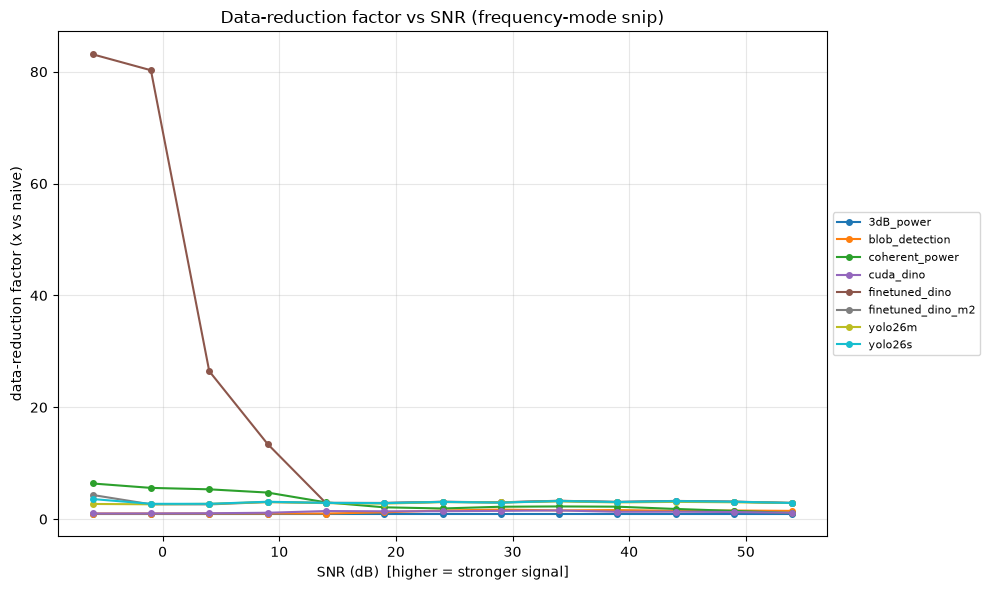

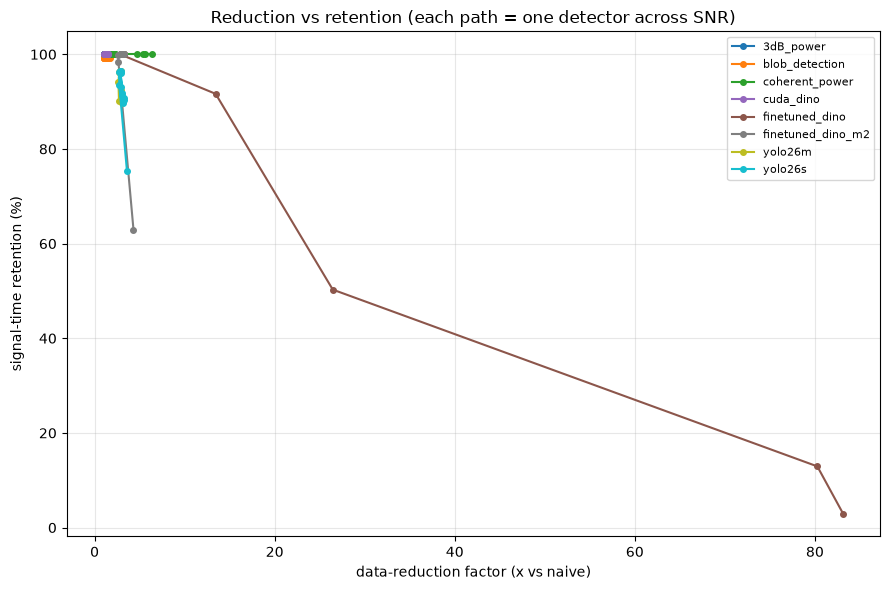

wrote SNR-axis figures -> /tmp/ds_batch/data_saving_figs


In [4]:
dets = sorted(df.detector.unique())
cmap = dict(zip(dets, plt.cm.tab10(np.linspace(0, 1, max(len(dets), 3)))))
naive = float(df.naive_TB_hr.iloc[0])

def _snr_fig(fname, ycol, ylab, title, log=True, ts=False):
    fig, ax = plt.subplots(figsize=(10, 6))
    if log:
        ax.axhline(naive, color="k", lw=2, label=f"naive save-all ({naive:.2f} TB/hr)")
    for det in dets:
        d = df[df.detector == det].sort_values("snr_db")
        ax.plot(d.snr_db, d[ycol], "-o", color=cmap[det], ms=4, label=det)
        if ts and has_ts:
            ax.plot(d.snr_db, d.timeslice_TB_hr, "--", color=cmap[det], alpha=.5)
    if log:
        ax.set_yscale("log")
    ax.set_xlabel("SNR (dB)  [higher = stronger signal]"); ax.set_ylabel(ylab)
    ax.set_title(title); ax.grid(alpha=.3, which="both")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1, .5)); fig.tight_layout()
    fig.savefig(OUT/fname, dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)

_snr_fig("stored_vs_snr_axis.png", "stored_TB_hr", "stored TB/hr (log)",
         "Data stored per hour vs SNR" + (" (solid=freq-mode, dashed=time-slice)" if has_ts else ""), log=True, ts=True)
_snr_fig("reduction_vs_snr.png", "reduction_x", "data-reduction factor (x vs naive)",
         "Data-reduction factor vs SNR (frequency-mode snip)", log=False)

# reduction vs retention (path per detector across SNR)
fig, ax = plt.subplots(figsize=(9, 6))
for det in dets:
    d = df[df.detector == det].sort_values("snr_db")
    ax.plot(d.reduction_x, 100*d.retention, "-o", color=cmap[det], ms=4, label=det)
ax.set_xlabel("data-reduction factor (x vs naive)"); ax.set_ylabel("signal-time retention (%)")
ax.set_title("Reduction vs retention (each path = one detector across SNR)")
ax.grid(alpha=.3); ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(OUT/"reduction_vs_retention_snr.png", dpi=110, bbox_inches="tight"); display(fig); plt.close(fig)
print(f"wrote SNR-axis figures -> {OUT}")